```text
=============================================================================
 myBytes.com  ·  Research notebook
 Copyright (c) 2026 myBytes GmbH. All rights reserved.
=============================================================================
```

# E-commerce conversion: early foresight vs end-of-session tautology

Companion research notebook to the myBytes note on honest e-commerce
session-conversion prediction
([mybytes.com/research/conversion-vorhersage-ecommerce](https://mybytes.com/research/conversion-vorhersage-ecommerce)).

Data: **Data Mining Cup 2013** ("prediction of orders") — anonymised real data
from a **generic online shop** (the task PDF establishes no vertical, so this is
general e-commerce, *not* a fashion study). ~50,000 sessions / ~429,000
transaction rows; per-session target `order` (y/n).

We reproduce the eye-catching near-perfect conversion AUC and show that most of
it is **basket tautology**: by the end of a session the basket state already
nearly encodes the outcome. Genuine *early* foresight is solid but far more
modest — and that is the number an intervention can actually use.

Data is not shipped (Kaggle / competition terms); see `DATA.md`.

## 1 · Setup and data

The file is `|`-separated, missing values are `?`. Each row is a transaction
(click); the `order` label is constant within a session (asserted below).

In [1]:
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OrdinalEncoder


def find_data():
    for pat in [str(Path.cwd().parent / "data/raw/*transact_train*"),
                str(Path.home() / ".cache/kagglehub/**/transact_train.txt")]:
        hits = sorted(glob.glob(pat, recursive=True))
        if hits:
            return hits[0]
    raise FileNotFoundError("transact_train.txt not found — see DATA.md")


df = pd.read_csv(find_data(), sep="|", na_values="?")
assert df.groupby("sessionNo")["order"].nunique().max() == 1, "order not constant within session"
print(f"{len(df):,} transaction rows   {df['sessionNo'].nunique():,} sessions")

429,013 transaction rows   50,000 sessions


## 2 · Session-level target and the scope caveat

We collapse to one row per session. The **first** transaction = what is known
after the first interaction; the **last** = the final (end-of-session) state.

In [2]:
NUM = ["startHour","startWeekday","duration","cCount","cMinPrice","cMaxPrice","cSumPrice",
       "bCount","bMinPrice","bMaxPrice","bSumPrice","bStep","maxVal","customerScore",
       "accountLifetime","age"]
CAT = ["onlineStatus","availability","address","payments","lastOrder"]
BASKET = ["bCount","bMinPrice","bMaxPrice","bSumPrice","bStep"]   # leak-prone end-state block
FEATS = NUM + CAT


def sframe(which):
    g = df.sort_values(["sessionNo","cCount"]).groupby("sessionNo", sort=True)
    r = (g.first() if which == "first" else g.last())
    r["y"] = (g["order"].last() == "y").astype(int)
    return r.reset_index()


first, last = sframe("first"), sframe("last")
base = float(first["y"].mean())
print(f"per-session order rate: {base:.1%}")
print("CAVEAT: this is the CURATED COMPETITION population, NOT a real funnel rate")
print("        (real e-commerce funnels convert in the low single digits).")

per-session order rate: 46.4%
CAVEAT: this is the CURATED COMPETITION population, NOT a real funnel rate
        (real e-commerce funnels convert in the low single digits).


## 3 · Leak-free validation: split by session, never by row

A session has many transaction rows sharing one label. A random or row-wise split
would put the same session in train and test — catastrophic leakage. We split by
`sessionNo` (oldest 80 % train, newest 20 % test).

In [3]:
cut = first["sessionNo"].quantile(0.80)
def split(d): return d[d["sessionNo"] <= cut], d[d["sessionNo"] > cut]


def fit_auc(tr, te, feats):
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    Xtr, Xte = tr[feats].copy(), te[feats].copy()
    cats = [c for c in CAT if c in feats]
    if cats:
        Xtr[cats] = enc.fit_transform(tr[cats].astype(str)); Xte[cats] = enc.transform(te[cats].astype(str))
    clf = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.08, max_depth=8, random_state=42)
    clf.fit(Xtr, tr["y"].values)
    return clf.predict_proba(Xte)[:, 1], float(roc_auc_score(te["y"].values, clf.predict_proba(Xte)[:, 1]))


f_tr, f_te = split(first); l_tr, l_te = split(last)
_, auc_early = fit_auc(f_tr, f_te, FEATS)
p_full, auc_full = fit_auc(l_tr, l_te, FEATS)
_, auc_nobasket = fit_auc(l_tr, l_te, [c for c in FEATS if c not in BASKET])
print(f"AUC early (first transaction)   : {auc_early:.3f}")
print(f"AUC full  (end-of-session state): {auc_full:.3f}")
print(f"AUC full WITHOUT basket block   : {auc_nobasket:.3f}")
print(f"foresight-vs-tautology gap      : {auc_full - auc_early:+.3f}")
print(f"basket-leakage contribution     : {auc_full - auc_nobasket:+.3f}")

AUC early (first transaction)   : 0.848
AUC full  (end-of-session state): 0.961
AUC full WITHOUT basket block   : 0.860
foresight-vs-tautology gap      : +0.114
basket-leakage contribution     : +0.101


The near-perfect 0.96 is mostly the basket block: removing it drops the full
model to ~0.86, right where the *early* model already sits. The end-of-session
basket state is close to a restatement of the outcome — impressive on a slide,
useless for acting early.

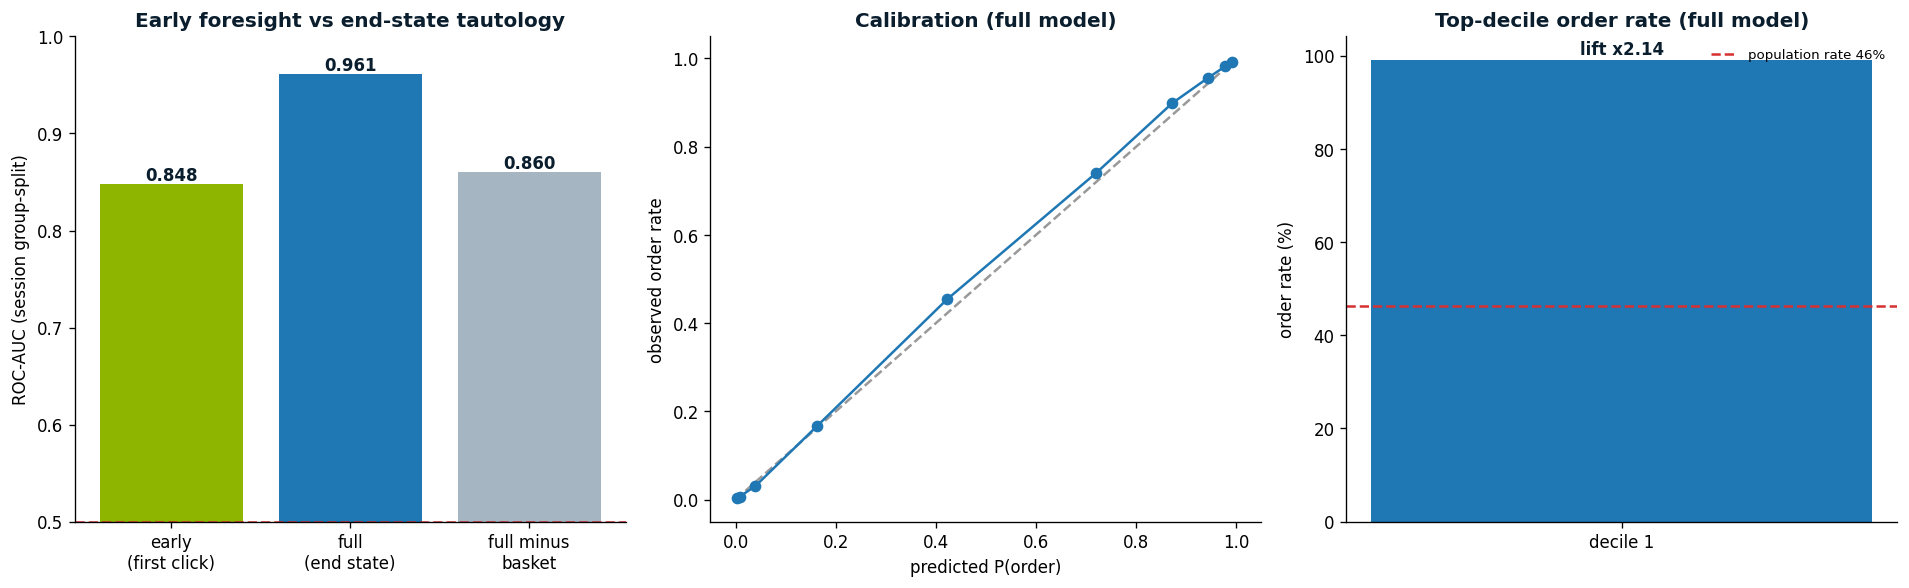

In [4]:
yte = l_te["y"].values
order = np.argsort(-p_full)
lift1 = yte[order[: len(order)//10]].mean() / base
fp, mp = calibration_curve(yte, p_full, n_bins=10, strategy="quantile")

INK, C1, C2, GREY, HI = "#0a1e2e", "#1f77b4", "#8eb600", "#A6B5C2", "#d63031"
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].bar(["early\n(first click)","full\n(end state)","full minus\nbasket"],
          [auc_early, auc_full, auc_nobasket], color=[C2, C1, GREY])
for i, v in enumerate([auc_early, auc_full, auc_nobasket]):
    ax[0].text(i, v+0.004, f"{v:.3f}", ha="center", fontweight="bold", color=INK)
ax[0].axhline(0.5, ls="--", color=HI); ax[0].set_ylim(0.5, 1.0)
ax[0].set_ylabel("ROC-AUC (session group-split)")
ax[0].set_title("Early foresight vs end-state tautology", fontweight="bold", color=INK)
ax[1].plot([0,1],[0,1],"--",color="#999"); ax[1].plot(mp, fp, "o-", color=C1)
ax[1].set_title("Calibration (full model)", fontweight="bold", color=INK)
ax[1].set_xlabel("predicted P(order)"); ax[1].set_ylabel("observed order rate")
ax[2].bar(["decile 1"], [yte[order[: len(order)//10]].mean()*100], color=C1)
ax[2].axhline(base*100, ls="--", color=HI, label=f"population rate {base:.0%}")
ax[2].text(0, yte[order[: len(order)//10]].mean()*100+1, f"lift x{lift1:.2f}", ha="center", fontweight="bold", color=INK)
ax[2].set_title("Top-decile order rate (full model)", fontweight="bold", color=INK)
ax[2].set_ylabel("order rate (%)"); ax[2].legend(frameon=False, fontsize=8)
for a in ax:
    for sp in ("top","right"): a.spines[sp].set_visible(False)
fig.tight_layout(); plt.show()

## Conclusion

- The dataset's **46.4 % order rate is a competition artefact**, not a real funnel
  rate — never quote it as a conversion benchmark.
- A near-perfect **end-of-session AUC (~0.96)** is largely **basket tautology**:
  drop the basket block and it falls to **~0.86**.
- **Early, actionable foresight** (from the first interaction) is **~0.85** — solid,
  honest, and the right basis for an intervention (a nudge, a coupon), not the
  tautological 0.96.

No euro cost-benefit is reported: there is no clean in-data margin/AOV anchor, and
inventing one would be the dishonest move. Method and licensing: `LICENSES.md`.